# Ablation Study

Table 3 reproduction: progressive AUC improvement through the
ensemble construction pipeline. Each step adds one component.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import roc_auc_score

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)

## Ablation Steps

Six progressive steps from a simple CatBoost on raw features
to the final band-gated ensemble submission.

In [2]:
oof_dir = Path('../results/oof')
metrics_dir = Path('../results/metrics')

# Load target
train = pd.read_csv('../data/competition/train.csv')
y = (train['Heart Disease'] == 'Presence').astype(int).values

# Ablation chain: each step builds on the previous
steps = [
    ('02_cb_raw', 'Step 1: CatBoost, raw 13 features'),
    ('cb_baseline', 'Step 2: + frequency encoding + UCI means (39 features)'),
    ('cb_origstats_f10_s42', 'Step 3: + full UCI stats + CB/XGB/RF stacking'),
    ('40_cb_lr_stack_blend', 'Step 4: Multi-seed cross-stacking blend'),
    ('hillclimb_v4', 'Step 5: Hill-climbing selection (5 candidates)'),
    ('rankgate_narrow_w5', 'Step 6: + band-gated diversity injection'),
]

rows = []
for model_id, description in steps:
    oof_path = oof_dir / f'{model_id}_oof.npy'
    if oof_path.exists():
        oof = np.load(oof_path)
        auc = roc_auc_score(y, oof)
        rows.append({'step': description, 'model_id': model_id, 'auc': auc})
    else:
        print(f'Missing OOF: {model_id}')

ablation_df = pd.DataFrame(rows)
ablation_df['delta'] = ablation_df['auc'].diff()
ablation_df

,step,model_id,auc,delta
0,"Step 1: CatBoost, raw 13 features",02_cb_raw,0.955503,NaN
1,Step 2: + frequency encoding + UCI means (39 f...,cb_baseline,0.955643,0.000140
2,Step 3: + full UCI stats + CB/XGB/RF stacking,cb_origstats_f10_s42,0.956264,0.000621
3,Step 4: Multi-seed cross-stacking blend,40_cb_lr_stack_blend,0.955708,-0.000557
4,Step 5: Hill-climbing selection (5 candidates),hillclimb_v4,0.955759,0.000052
5,Step 6: + band-gated diversity injection,rankgate_narrow_w5,0.955884,0.000124


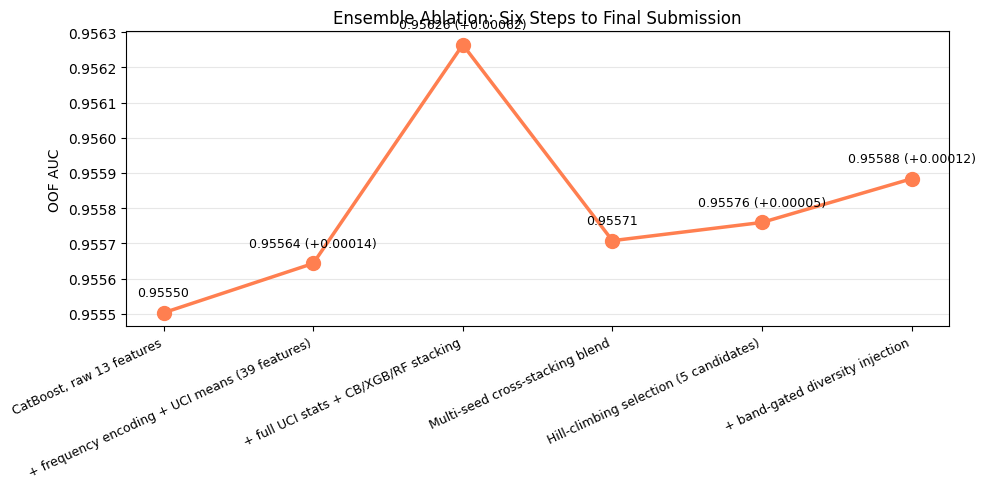

In [3]:
# Ablation curve
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(len(ablation_df)), ablation_df['auc'], 'o-', color='coral',
        markersize=10, linewidth=2.5)

for i, row in ablation_df.iterrows():
    label = f"{row['auc']:.5f}"
    if pd.notna(row['delta']) and row['delta'] > 0:
        label += f" (+{row['delta']:.5f})"
    ax.annotate(label, (i, row['auc']), textcoords='offset points',
                xytext=(0, 12), ha='center', fontsize=9)

ax.set_xticks(range(len(ablation_df)))
short_labels = [s.split(': ')[1] if ': ' in s else s for s in ablation_df['step']]
ax.set_xticklabels(short_labels, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('OOF AUC')
ax.set_title('Ensemble Ablation: Six Steps to Final Submission')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/figures/ablation_six_steps.png', dpi=150, bbox_inches='tight')
plt.show()

## Observations

- Feature engineering (Steps 1-3) contributes the largest single gain
- Per-fold stacking (CB+XGB+RF) further improves over single CatBoost
- Ensemble blending and hill-climbing provide incremental but consistent gains
- Band-gated injection adds the final diversity component